In [1]:
from transformers import AutoTokenizer, AutoModelForCausalLM

tokenizer = AutoTokenizer.from_pretrained("EleutherAI/pythia-1b")
model = AutoModelForCausalLM.from_pretrained("EleutherAI/pythia-1b")

/Users/eryk/Documents/Praca magisterska/llms-facts-representation/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
seq = "Krakow is a city in"
inputs = tokenizer(seq, return_tensors="pt")
outputs = model(**inputs)
logits = outputs.logits
print(logits)

tensor([[[  3.1915,  -6.4988,   4.5337,  ...,  -6.4201,  -6.4522,  -6.6416],
         [  5.0947,  -6.3168,   7.0813,  ...,  -6.2180,  -6.2824,  -6.5845],
         [  6.6454, -10.0107,   6.5736,  ...,  -9.8344, -10.1360, -10.1632],
         ...,
         [  2.3294,  -8.5299,   0.5062,  ...,  -8.2598,  -8.4477,  -8.3482],
         [  5.2362,  -7.7561,   6.7092,  ...,  -7.5044,  -7.6889,  -7.7835],
         [  1.0455,  -8.7930,   2.7660,  ...,  -8.5230,  -8.4526,  -8.5196]]],
       grad_fn=<UnsafeViewBackward0>)


In [3]:
import torch

probs = torch.nn.functional.softmax(logits, dim=-1)

topk = 10
top_probs, top_indices = torch.topk(probs[:, -1, :], topk)

for i in range(topk):
    token_id = top_indices[0, i].item()
    token_prob = top_probs[0, i].item()
    token = tokenizer.decode(token_id)
    print(f"Token: {token} (id: {token_id}) - Probability: {token_prob:.6f}")

Token:  the (id: 253) - Probability: 0.353255
Token:  Poland (id: 16795) - Probability: 0.164589
Token:  K (id: 611) - Probability: 0.049737
Token:  southern (id: 11053) - Probability: 0.049043
Token:  S (id: 322) - Probability: 0.034955
Token:  south (id: 6420) - Probability: 0.033360
Token:  eastern (id: 14730) - Probability: 0.028237
Token:  Greater (id: 28319) - Probability: 0.023397
Token:  western (id: 10439) - Probability: 0.022736
Token:  central (id: 4275) - Probability: 0.018294


In [4]:
# seq = "The Eiffel Tower is located in"
inputs = tokenizer(seq, return_tensors="pt")
output = model.generate(
    **inputs,
    max_new_tokens=50,
    do_sample=True,
    temperature=0.8,
    top_p=0.9,
    eos_token_id=tokenizer.eos_token_id,
    pad_token_id=tokenizer.eos_token_id
)
print(tokenizer.decode(output[0], skip_special_tokens=True))


Krakow is a city in the southeastern part of the Polish Voivodeship (southeastern Poland). It is located on the eastern edge of the Lesser Poland, on the right bank of the Dniester River, at the confluence of the Dniester


In [5]:
#Extracting residual stream activations

inputs = tokenizer(seq, return_tensors="pt")
print(inputs)
with torch.no_grad():
    out = model(**inputs, output_hidden_states=True, output_attentions=False)
print(out)

{'input_ids': tensor([[   44, 21720,   319,   310,   247,  2846,   275]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1]])}
CausalLMOutputWithPast(loss=None, logits=tensor([[[  3.1915,  -6.4988,   4.5337,  ...,  -6.4201,  -6.4522,  -6.6416],
         [  5.0947,  -6.3168,   7.0813,  ...,  -6.2180,  -6.2824,  -6.5845],
         [  6.6454, -10.0107,   6.5736,  ...,  -9.8344, -10.1360, -10.1632],
         ...,
         [  2.3294,  -8.5299,   0.5062,  ...,  -8.2598,  -8.4477,  -8.3482],
         [  5.2362,  -7.7561,   6.7092,  ...,  -7.5044,  -7.6889,  -7.7835],
         [  1.0455,  -8.7930,   2.7660,  ...,  -8.5230,  -8.4526,  -8.5196]]]), past_key_values=DynamicCache(layers=[DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer]), hidden_states=(tensor([[[ 0.0059,  0.0249, -0.0112,  ...,  0.0216, -0.0220,  0.0222],
     

In [6]:
decoded = tokenizer.decode(inputs["input_ids"].squeeze().tolist(),
                           skip_special_tokens=False,
                           clean_up_tokenization_spaces=False)

ids = inputs["input_ids"].squeeze().tolist()
token_id_to_str = {tid: tokenizer.decode([tid],
                                         skip_special_tokens=False,
                                         clean_up_tokenization_spaces=False)
                   for tid in ids}

print(token_id_to_str)
print(repr(decoded))

tokens_repr = token_id_to_str.values()

{44: 'K', 21720: 'rak', 319: 'ow', 310: ' is', 247: ' a', 2846: ' city', 275: ' in'}
'Krakow is a city in'


Layer 0 decoded tokens:  Racingweights Instantaloysetintropartum
Layer 1 decoded tokens: urtootlsomerzitterscapezitter
Layer 2 decoded tokens: losunkavezitterzitter theoretzitter
Layer 3 decoded tokens: ��unkavezitter ■ theoret ■
Layer 4 decoded tokens:  ■utave alsoktivwide the
Layer 5 decoded tokens:  ■ut/ also very theoretiae
Layer 6 decoded tokens:  ■ty, also�� theoretskirts
Layer 7 decoded tokens:  ■ut, also very ■ije
Layer 8 decoded tokens:  ■utsky also very theoret the
Layer 9 decoded tokens:  ■utsky also very theoret the
Layer 10 decoded tokens:  ■ut, also very of the
Layer 11 decoded tokens:  ■un, the very of the
Layer 12 decoded tokens:  ■un, a very in the
Layer 13 decoded tokens:  ■-, a very in the
Layer 14 decoded tokens:  ■-- a very- the
Layer 15 decoded tokens:  ■-, a
- the
Layer 16 decoded tokens: _ow, a city in the


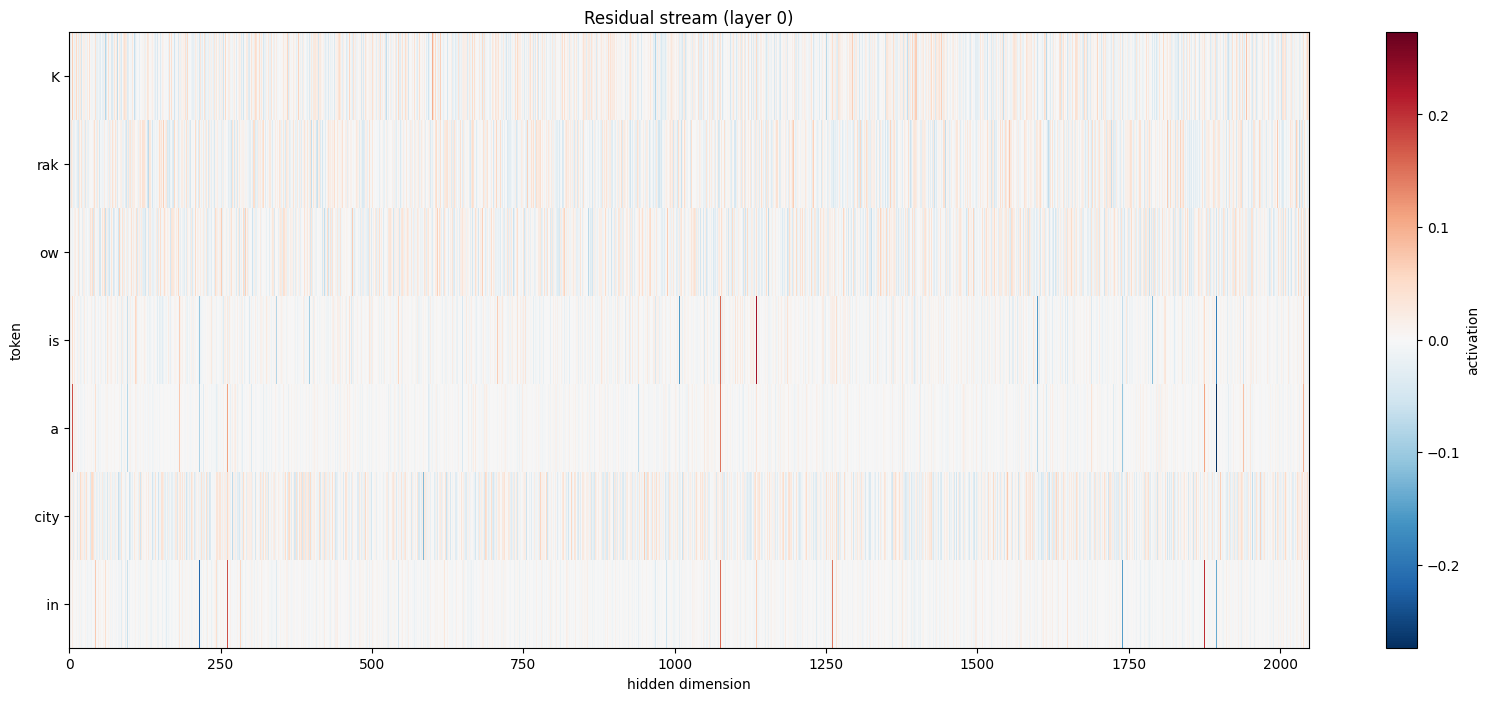

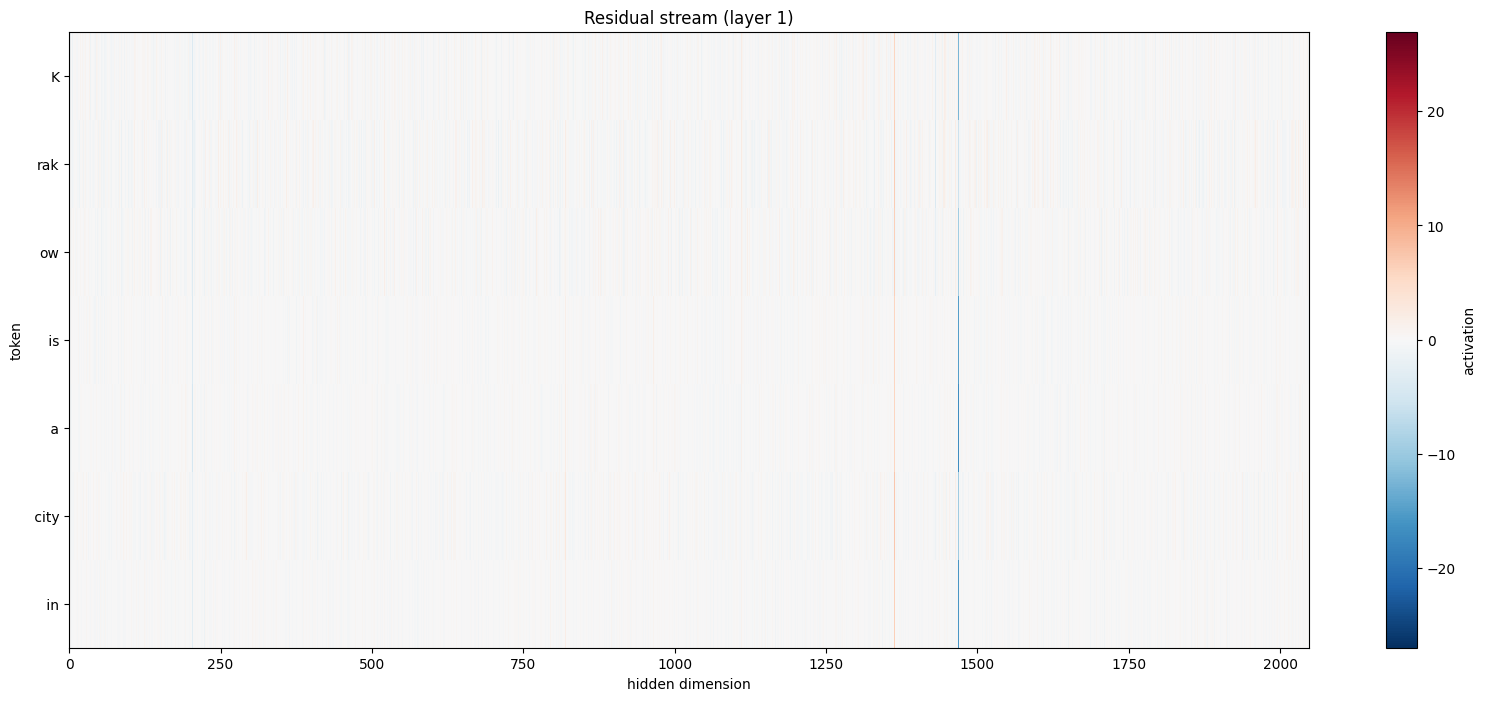

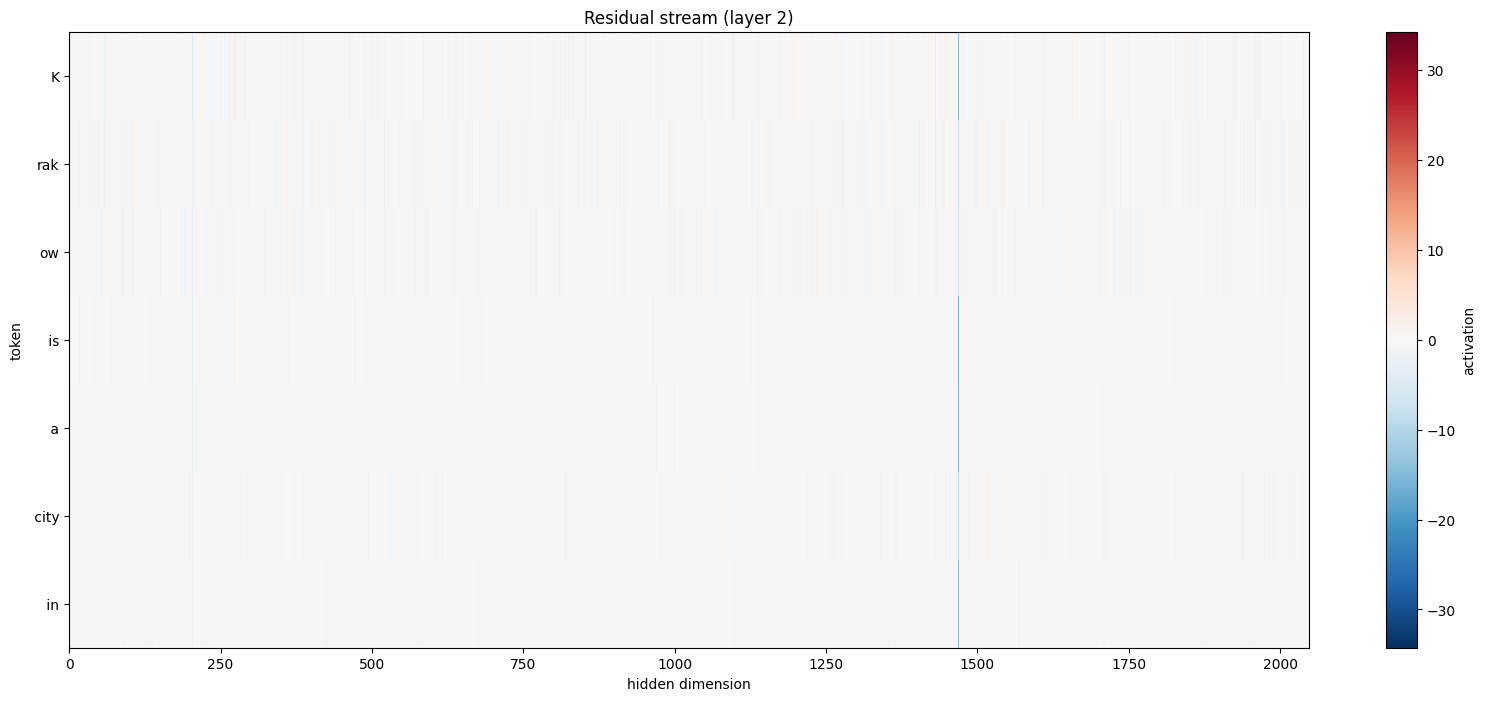

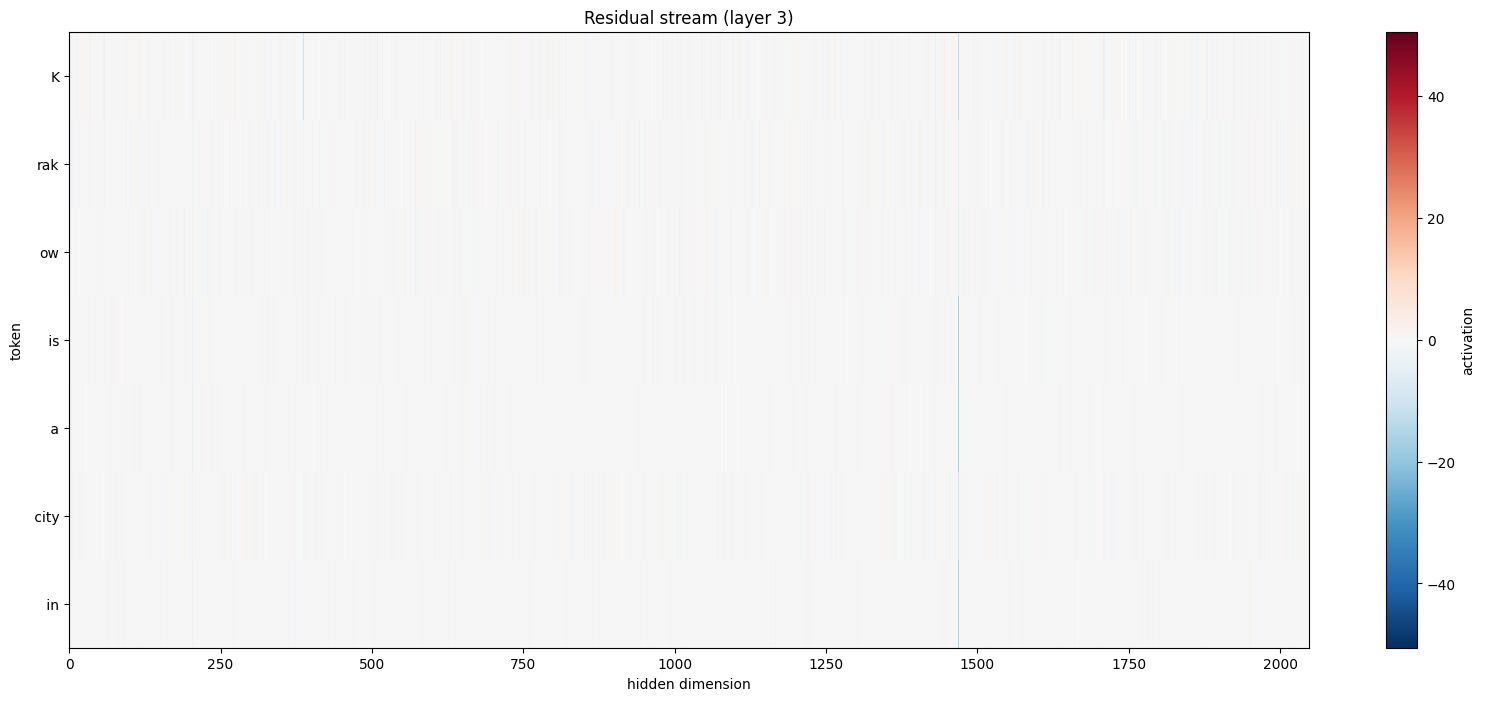

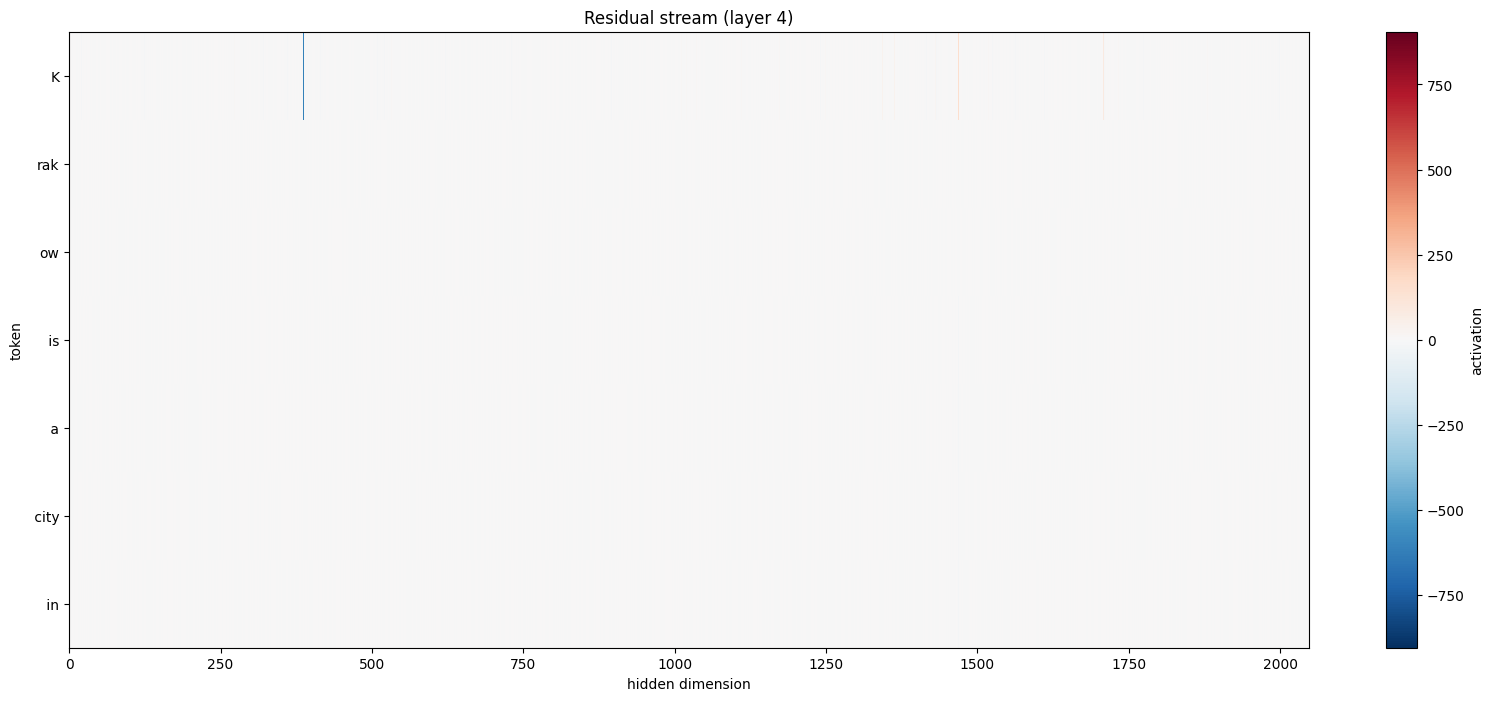

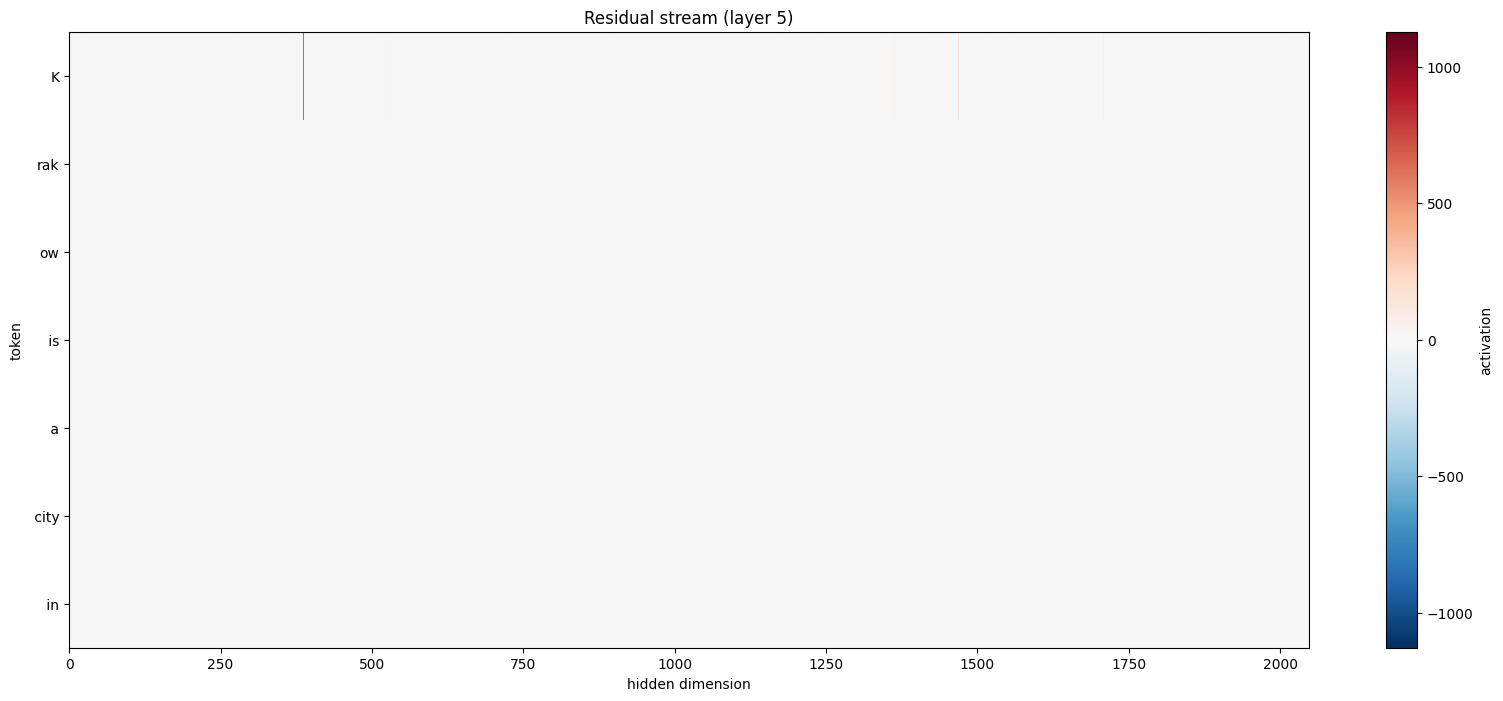

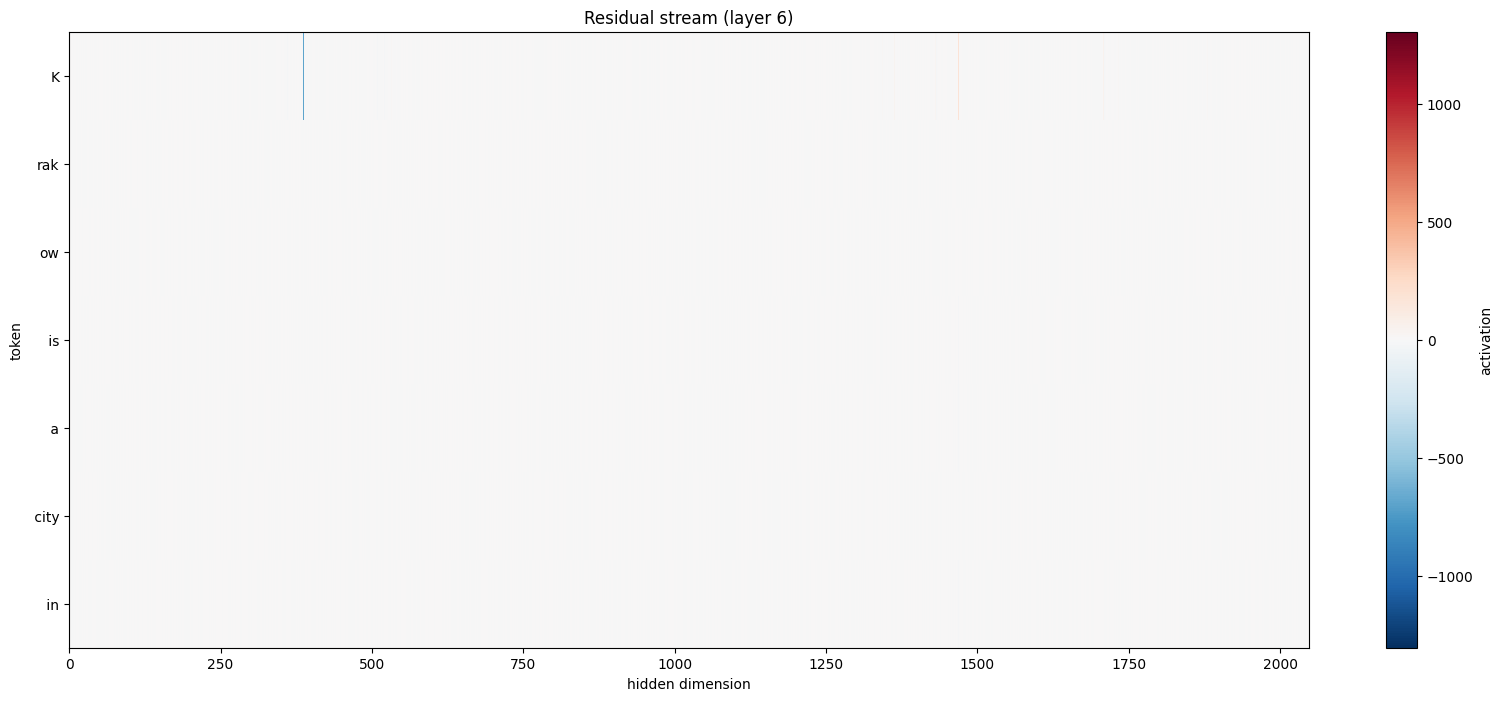

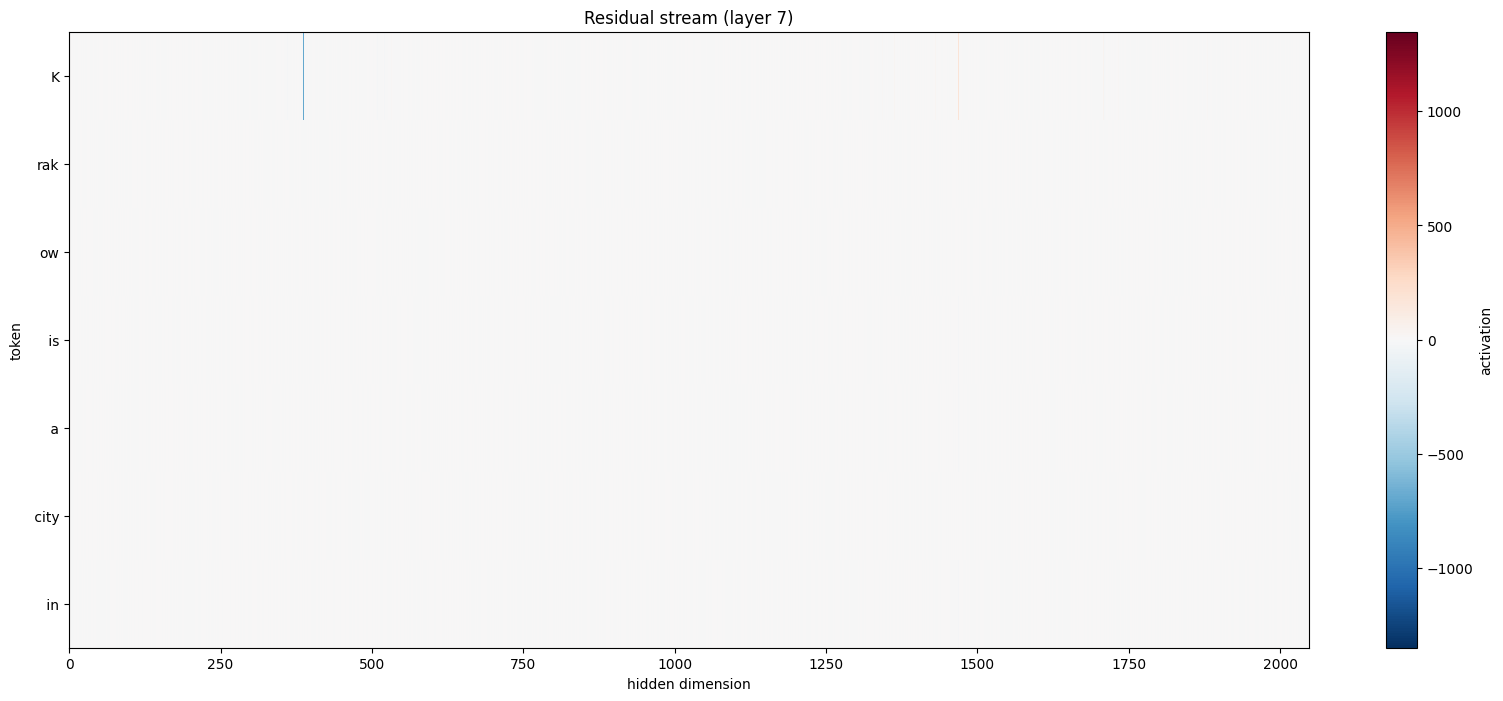

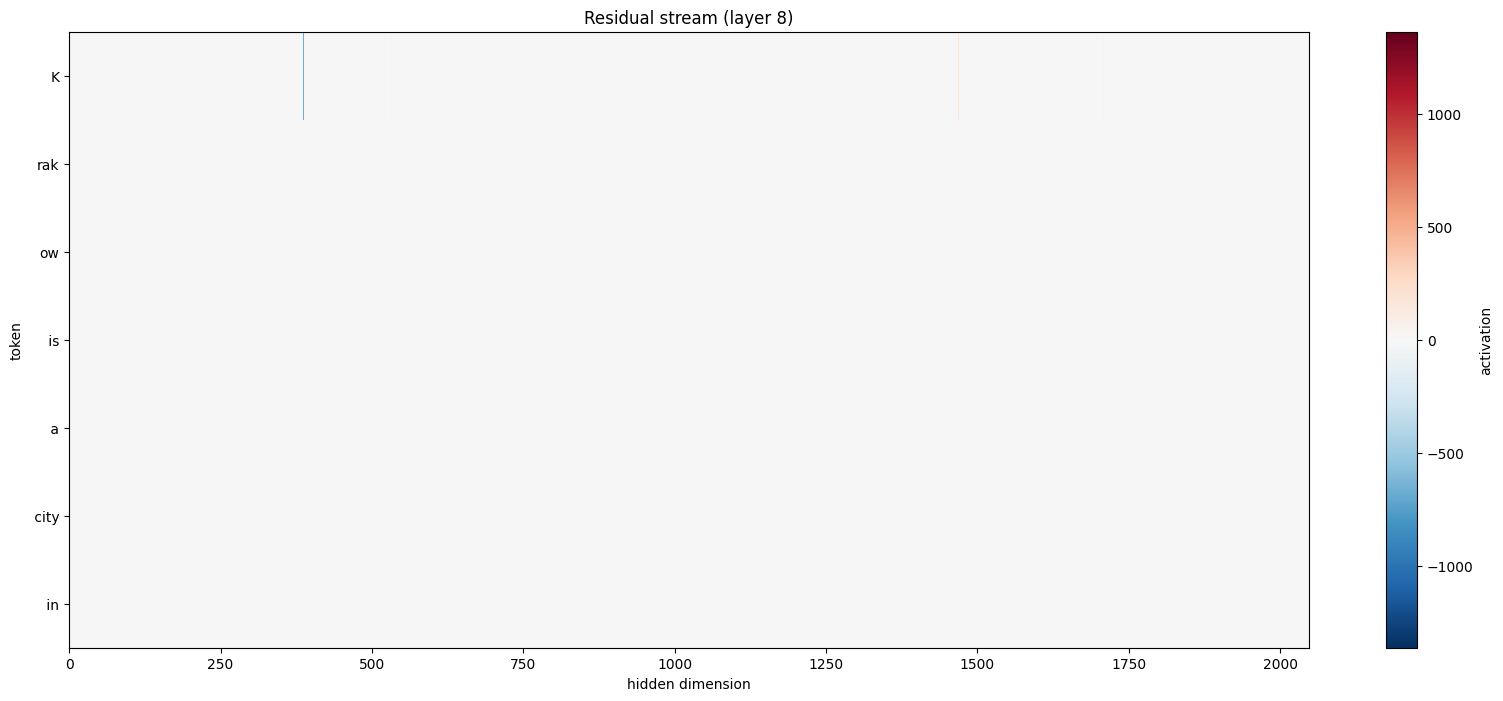

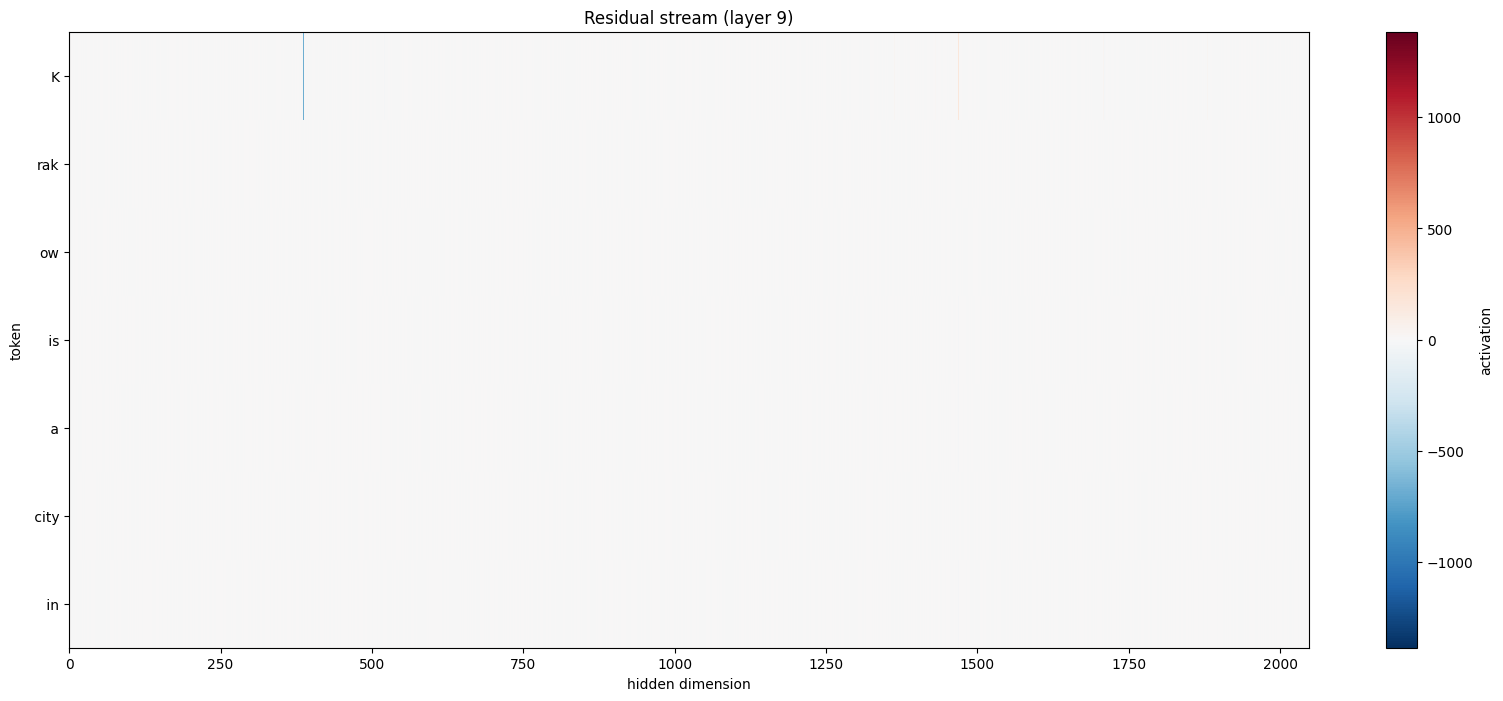

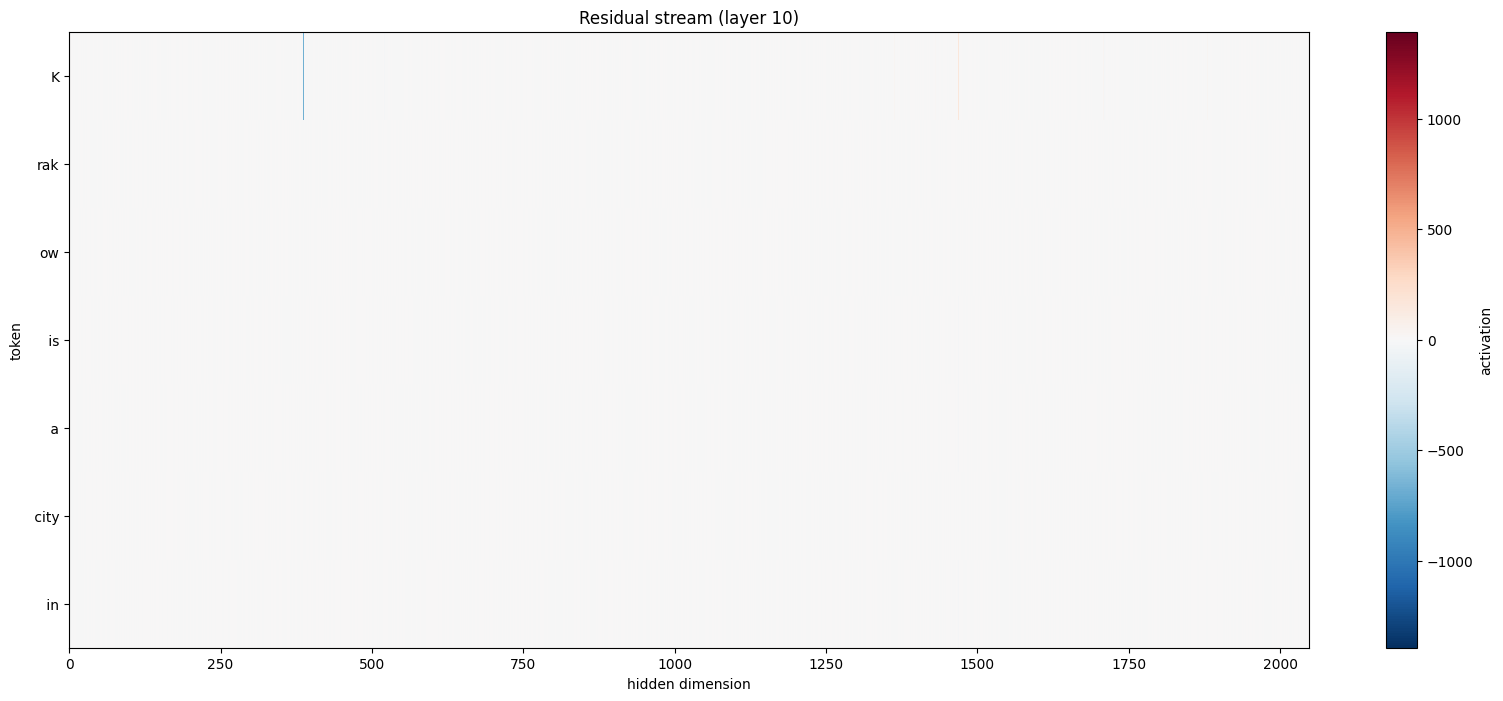

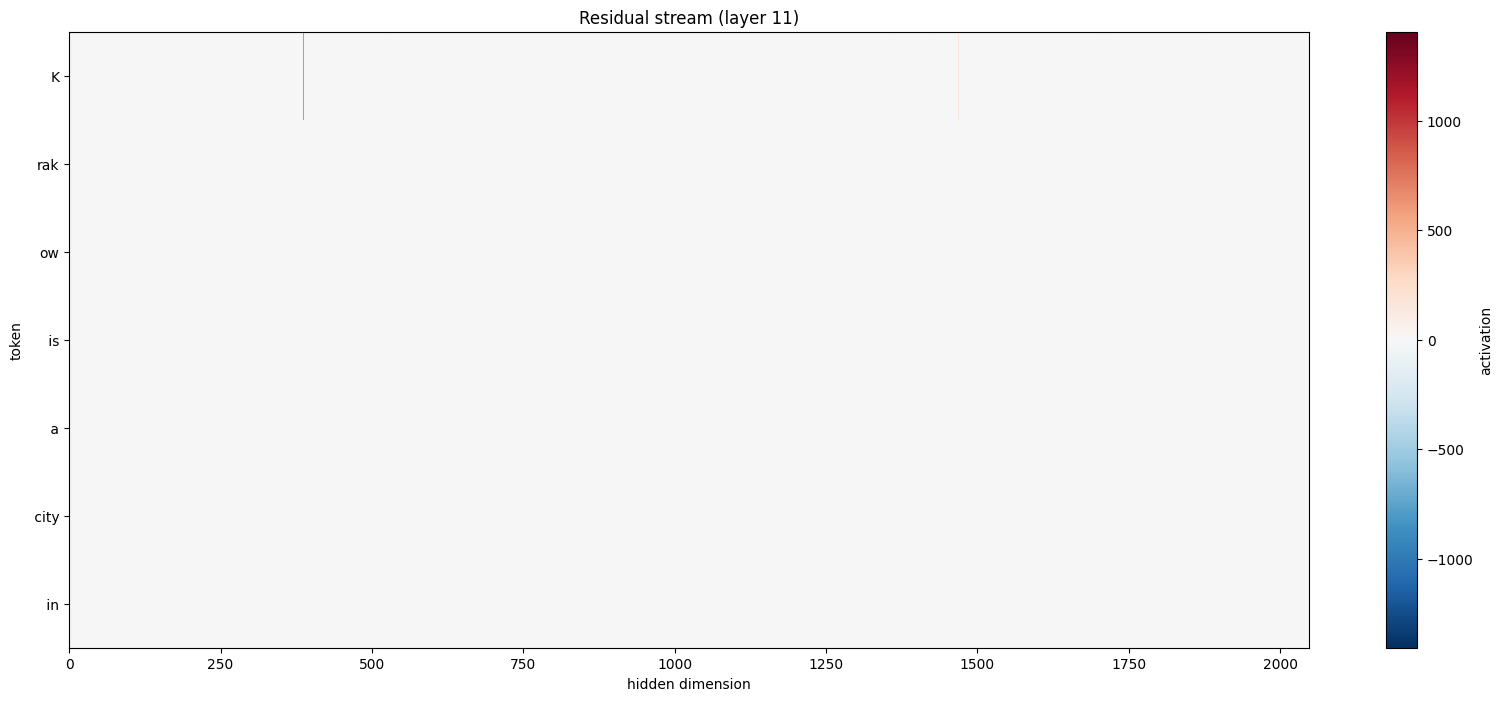

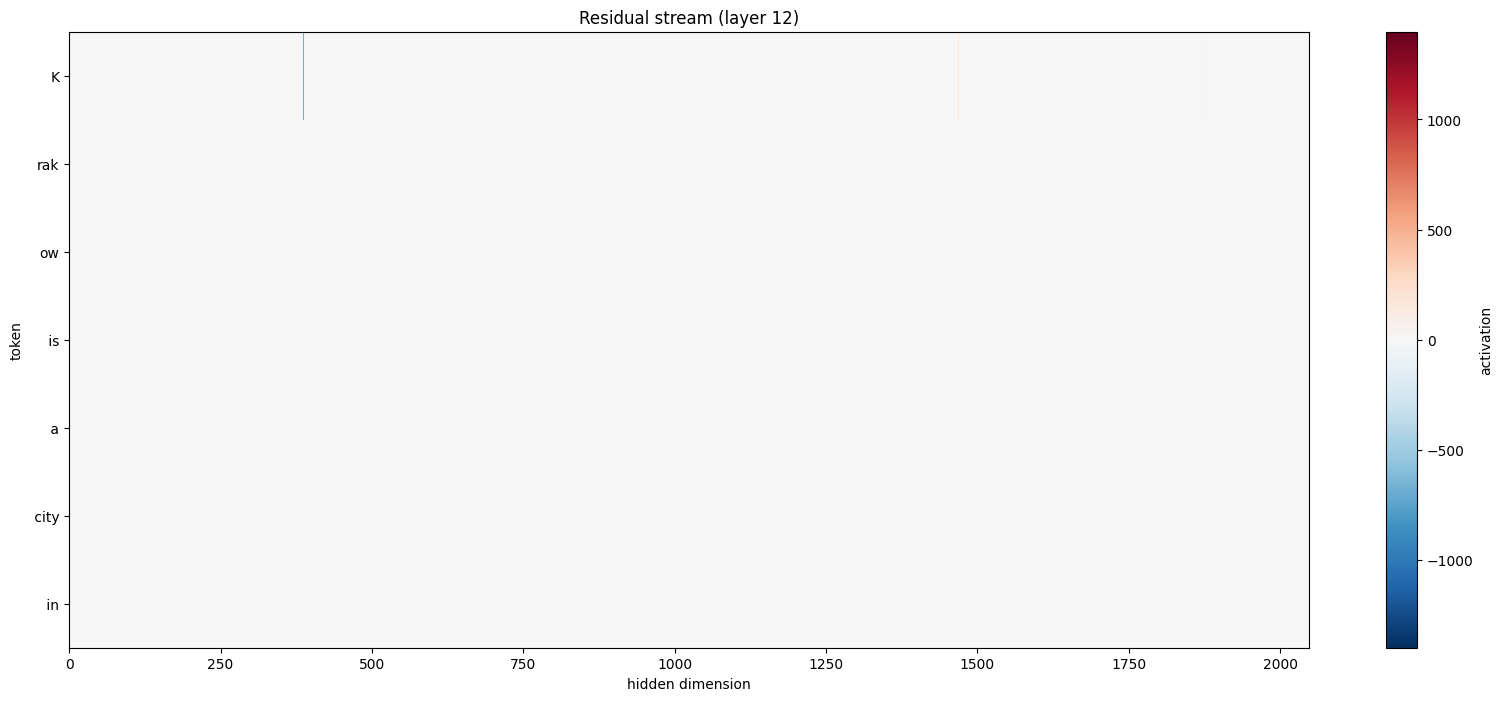

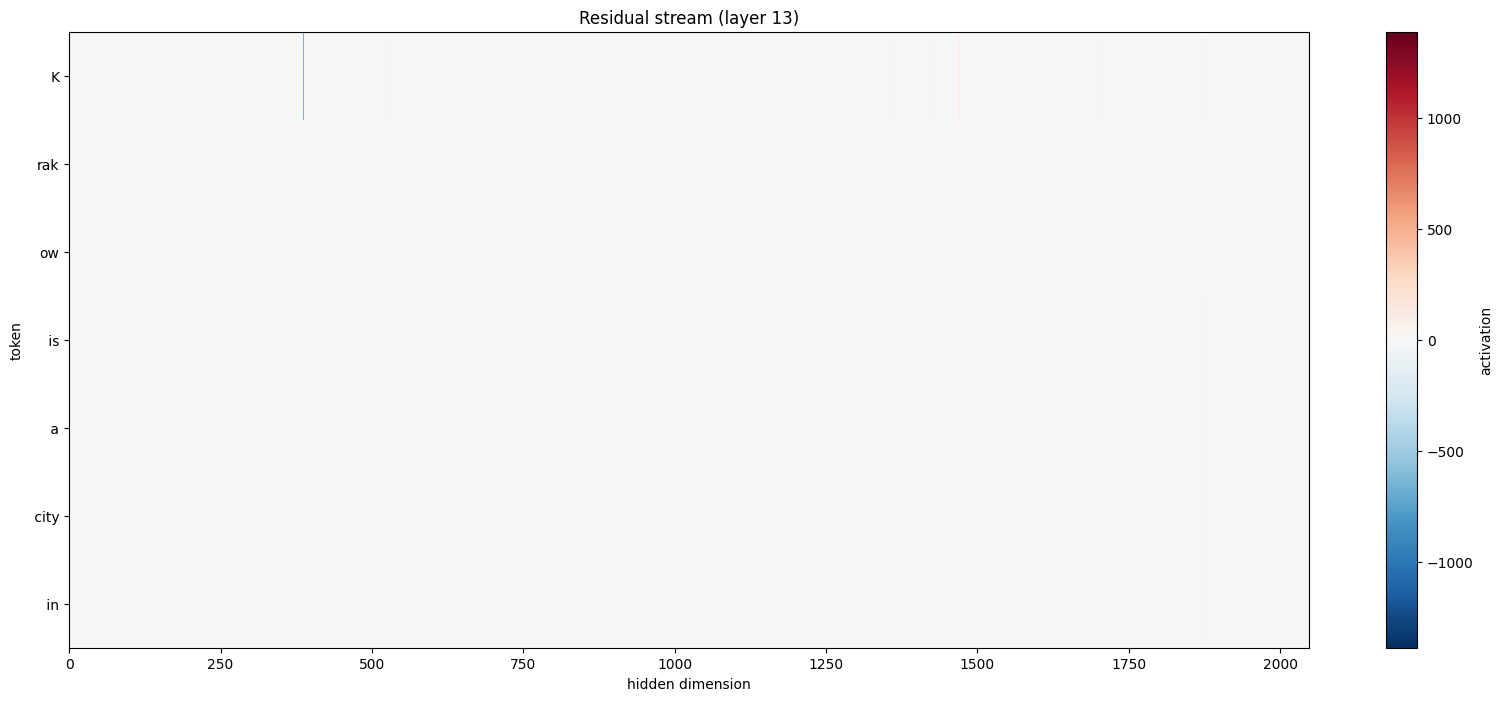

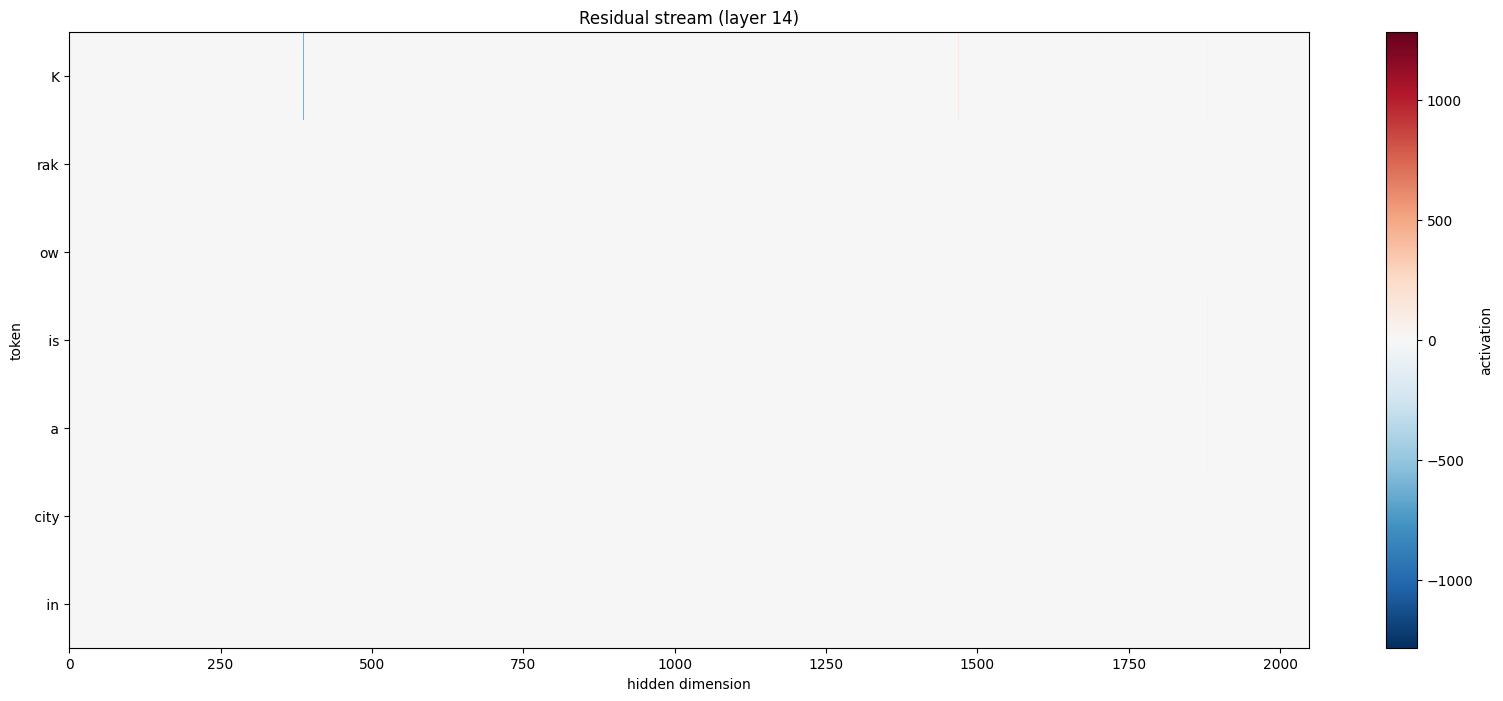

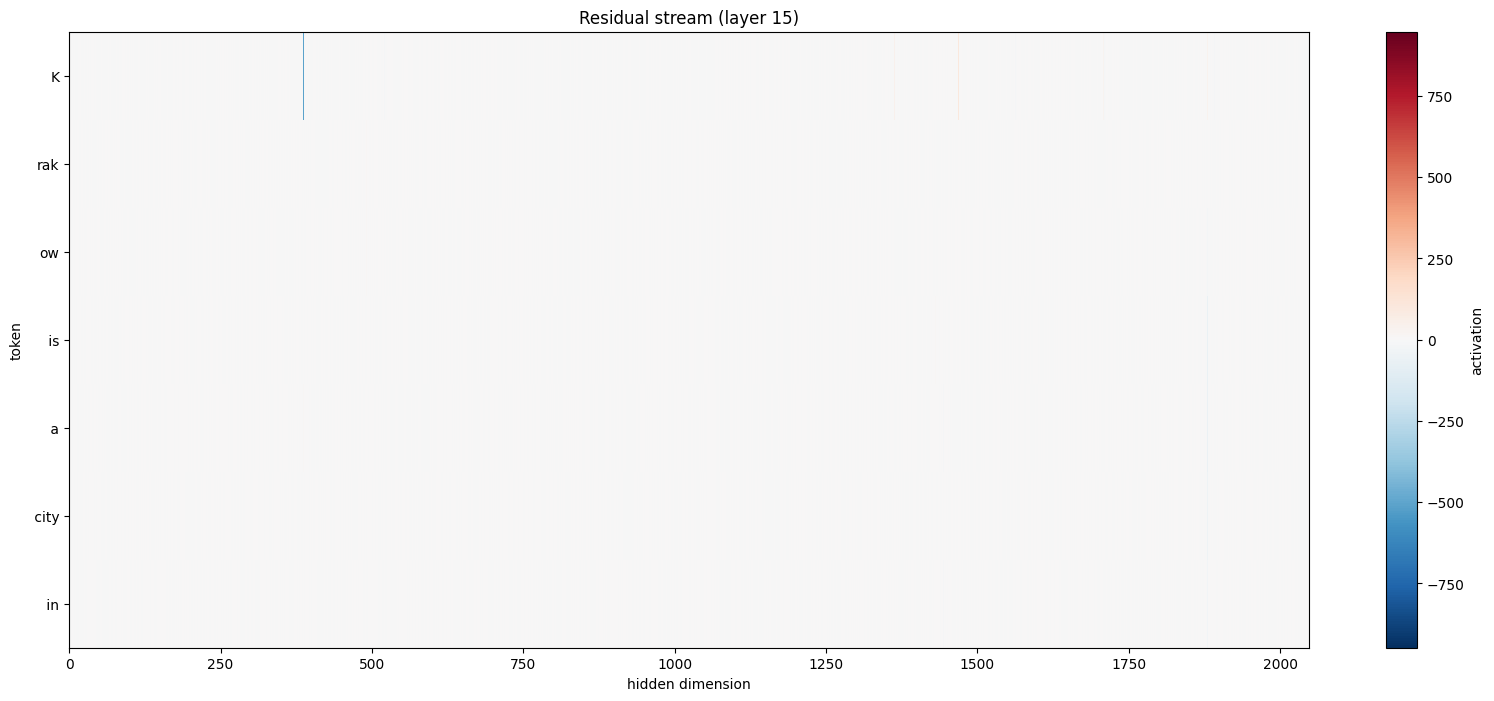

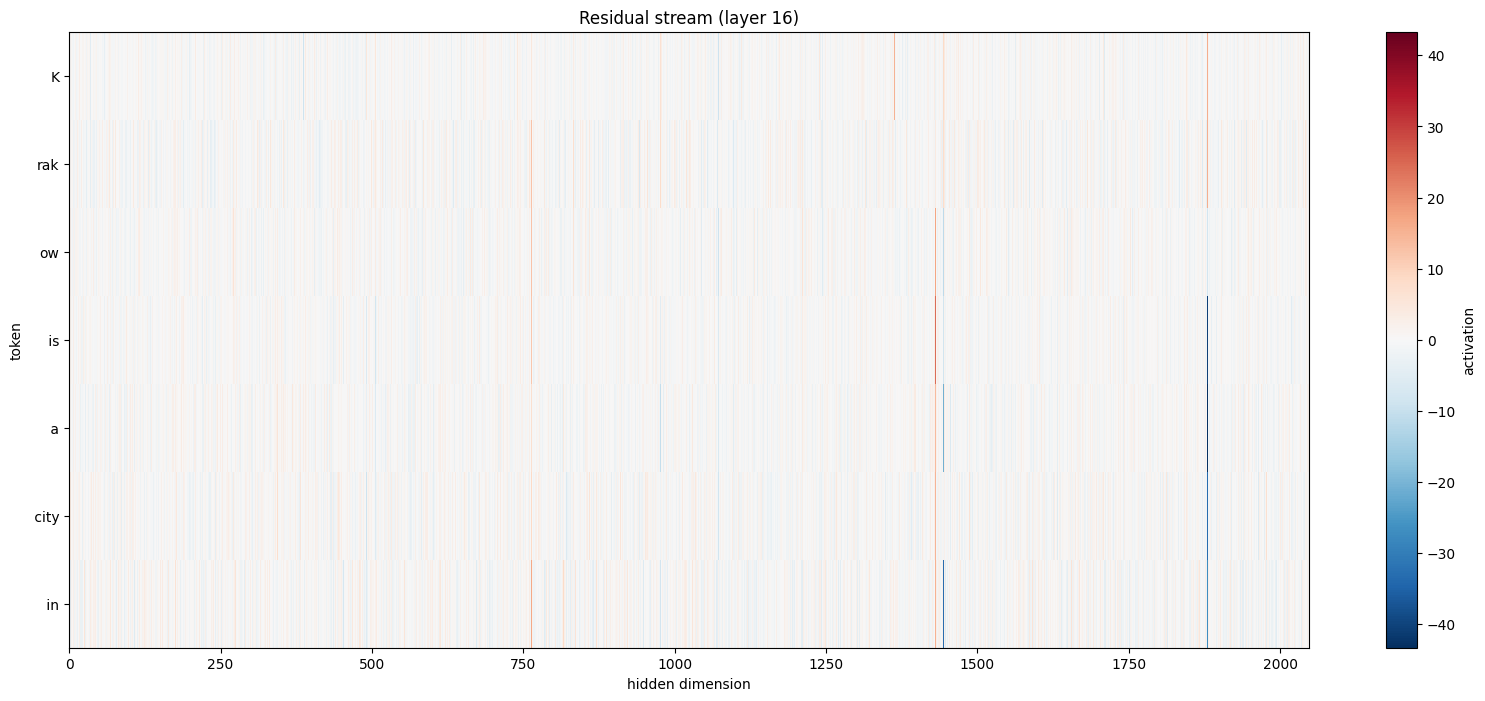

In [7]:
import matplotlib.pyplot as plt

residual_streams = out.hidden_states
for i, stream in enumerate(residual_streams):
    v = stream.squeeze()
    # Project residual stream back into vocabulary logits
    vocab_logits = model.embed_out(torch.tensor(v, dtype=torch.float32) if not isinstance(v, torch.Tensor) else v)
    decoded_tokens_from_layer = tokenizer.decode(torch.argmax(vocab_logits, dim=-1).tolist())
    print(f"Layer {i} decoded tokens: {decoded_tokens_from_layer}")
    # vocab_logits shape: (tokens, vocab_size)
    if hasattr(v, "detach"):
        v = v.detach().cpu().numpy()

    plt.figure(figsize=(20, 8))
    max_abs = abs(v).max() if v.size else None
    plt.imshow(v, aspect='auto', interpolation='nearest', cmap='RdBu_r', vmin=-max_abs, vmax=max_abs)
    plt.colorbar(label='activation')
    plt.xlabel('hidden dimension')
    plt.ylabel('token')
    plt.yticks(range(v.shape[0]), tokens_repr)
    # plt.yticks(words)
    plt.title(f'Residual stream (layer {i})')

In [8]:
top_k = 10

for i, stream in enumerate(residual_streams):
    v = stream.squeeze()
    vocab_logits = model.embed_out(torch.tensor(v, dtype=torch.float32) if not isinstance(v, torch.Tensor) else v)
    last_token = torch.topk(vocab_logits, k=top_k, dim=-1).indices[-1, :]
    decoded_tokens_from_layer = [tokenizer.decode([tid.item()]) for tid in last_token]
    print(f"Layer {i} top tokens for last position: {decoded_tokens_from_layer}")


Layer 0 top tokens for last position: ['partum', '(-', ' chains', 'bab', 'aggio', ' standards', '^-', 'raint', 'ARP', 'verte']
Layer 1 top tokens for last position: ['zitter', ' keeping', 'alion', ' ener', ' the', 'iae', 'hern', 'ows', ' association', 'izen']
Layer 2 top tokens for last position: ['zitter', 'iae', ' keeping', 'alion', ' place', 'hern', ' ener', ' theoret', 'skirts', 'ون']
Layer 3 top tokens for last position: [' ■', 'zitter', 'iae', ' the', ' place', ' theoret', '��', 'significant', 'jas', ' significant']
Layer 4 top tokens for last position: [' the', ' significant', ' its', 'iae', ' place', ' keeping', 'hern', ' specifically', ' advance', 'zitter']
Layer 5 top tokens for last position: ['iae', ' significant', 'skirts', 'rar', ' ■', 'ITER', 'rt', 'ometown', ' its', 'und']
Layer 6 top tokens for last position: ['skirts', ' ■', 'hern', 'isel', 'iae', 'zitter', 'vez', 'ije', 'und', 'rar']
Layer 7 top tokens for last position: ['ije', 'lc', ' the', 'sein', ' ■', 'und', 'is

Looking at the activations of target words:

Token IDs:
' the' -> ID: 253
' Poland' -> ID: 16795
' southern' -> ID: 11053
' south' -> ID: 6420
' eastern' -> ID: 14730
' east' -> ID: 9268
' western' -> ID: 10439
'west' -> ID: 8535
'northen' -> ID: 864
'north' -> ID: 37436
' central' -> ID: 4275
'Greater' -> ID: 254
'Małopolska' -> ID: 4530
'Krakow' -> ID: 319
' city' -> ID: 2846
' capital' -> ID: 5347


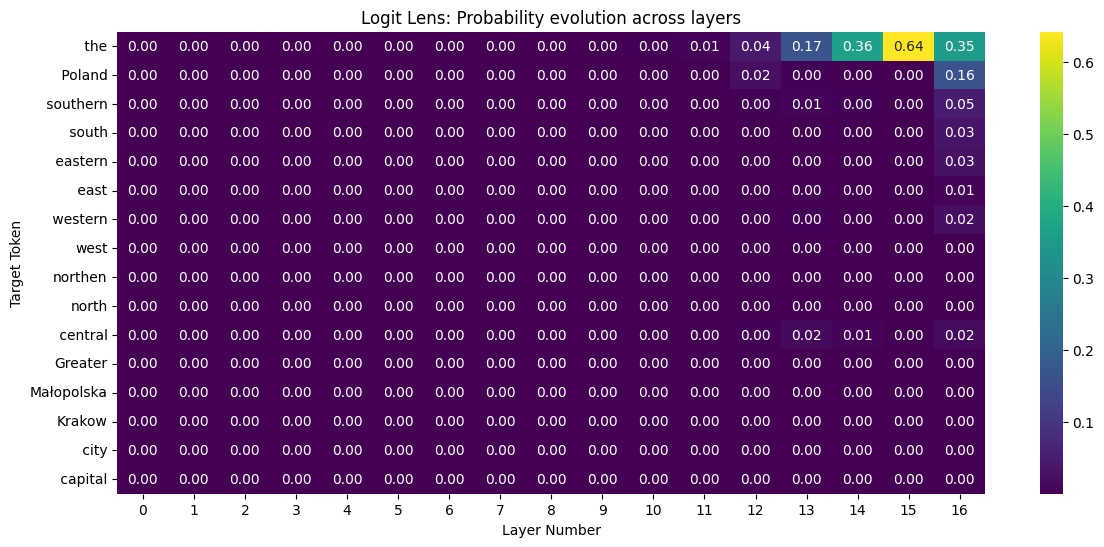

In [9]:
import seaborn as sns
import numpy as np

target_words = [' the', ' Poland', ' southern', ' south', ' eastern', ' east', ' western', 'west', 'northen', 'north',' central', 'Greater', 'Małopolska', 'Krakow', ' city', ' capital']

target_ids = []
found_labels = []

print("Token IDs:")
for word in target_words:
    # encode może zwracać listę, bierzemy ID. 
    # add_special_tokens=False żeby nie dodawać BOS/EOS jeśli nie trzeba
    ids = tokenizer.encode(word, add_special_tokens=False)
    
    # Zabezpieczenie: bierzemy ostatni ID (jeśli słowo rozbiło się na pod-tokeny)
    if len(ids) > 0:
        tid = ids[-1] 
        target_ids.append(tid)
        found_labels.append(word)
        print(f"'{word}' -> ID: {tid}")
    else:
        print(f"Warning: '{word}' nie znaleziono w słowniku.")

# --- 2. ZBIERANIE DANYCH ---
# Macierz: wiersze = warstwy, kolumny = nasze target tokeny
probs_history = []

for i, stream in enumerate(residual_streams):
    v = stream.squeeze()
    
    # Upewnij się, że v to tensor float32
    if not isinstance(v, torch.Tensor):
        v = torch.tensor(v, dtype=torch.float32)
    
    # Pobierz wektor tylko dla OSTATNIEJ pozycji w sekwencji (tam gdzie model zgaduje 'next token')
    # Jeśli v ma kształt [seq_len, hidden_dim], bierzemy ostatni wiersz
    if v.ndim > 1:
        final_vector = v[-1, :]
    else:
        final_vector = v

    # Projekcja na słownik (Logity)
    # UWAGA: Dla pełnej poprawności naukowej, przed embed_out powinieneś 
    # zaaplikować LayerNorm (model.ln_final), jeśli embed_out tego nie robi.
    vocab_logits = model.embed_out(final_vector)
    
    # Zmieniamy logity na prawdopodobieństwa (0.0 - 1.0) używając Softmax
    # To sprawia, że warstwy są porównywalne
    vocab_probs = torch.softmax(vocab_logits, dim=-1)
    
    # Wyciągamy prawdopodobieństwa tylko dla naszych targetów
    current_layer_probs = [vocab_probs[tid].item() for tid in target_ids]
    probs_history.append(current_layer_probs)

# --- 3. WIZUALIZACJA ---
# Konwersja do numpy i transpozycja (żeby Warstwy były na osi X, a Tokeny na Y)
data = np.array(probs_history).T 

plt.figure(figsize=(14, 6))
sns.heatmap(
    data, 
    annot=True,            # Pokaż liczby w kratkach
    fmt=".2f",             # Formatowanie liczb (2 miejsca po przecinku)
    cmap="viridis",        # Kolorystyka (ciemny = 0, jasny = 1)
    xticklabels=range(len(residual_streams)), # Oś X: Warstwy
    yticklabels=found_labels                  # Oś Y: Tokeny
)

plt.xlabel("Layer Number")
plt.ylabel("Target Token")
plt.title("Logit Lens: Probability evolution across layers")
plt.show()

Token IDs:
' the' -> ID: 253
' Poland' -> ID: 16795
' southern' -> ID: 11053
' south' -> ID: 6420
' eastern' -> ID: 14730
' east' -> ID: 9268
' western' -> ID: 10439
'west' -> ID: 8535
'northen' -> ID: 864
'north' -> ID: 37436
' central' -> ID: 4275
'Greater' -> ID: 254
'Małopolska' -> ID: 4530
'Krakow' -> ID: 319
' city' -> ID: 2846
' capital' -> ID: 5347


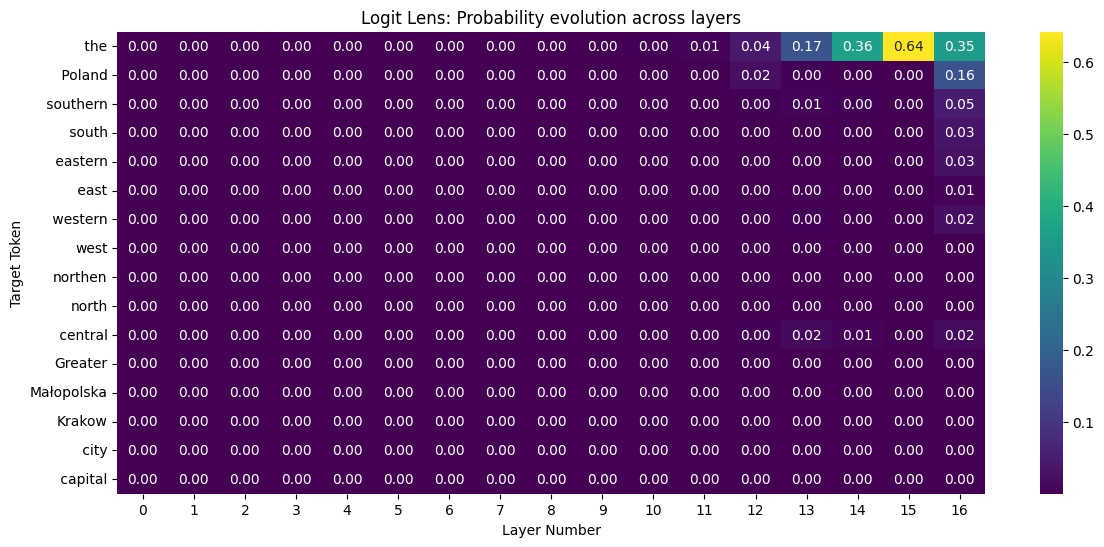

In [10]:
target_ids = []
found_labels = []

print("Token IDs:")
for word in target_words:
    # encode może zwracać listę, bierzemy ID. 
    # add_special_tokens=False żeby nie dodawać BOS/EOS jeśli nie trzeba
    ids = tokenizer.encode(word, add_special_tokens=False)
    
    # Zabezpieczenie: bierzemy ostatni ID (jeśli słowo rozbiło się na pod-tokeny)
    if len(ids) > 0:
        tid = ids[-1] 
        target_ids.append(tid)
        found_labels.append(word)
        print(f"'{word}' -> ID: {tid}")
    else:
        print(f"Warning: '{word}' nie znaleziono w słowniku.")

# --- 2. ZBIERANIE DANYCH ---
# Macierz: wiersze = warstwy, kolumny = nasze target tokeny
probs_history = []

for i, stream in enumerate(residual_streams):
    v = stream.squeeze()
    
    # Upewnij się, że v to tensor float32
    if not isinstance(v, torch.Tensor):
        v = torch.tensor(v, dtype=torch.float32)
    
    # Pobierz wektor tylko dla OSTATNIEJ pozycji w sekwencji (tam gdzie model zgaduje 'next token')
    # Jeśli v ma kształt [seq_len, hidden_dim], bierzemy ostatni wiersz
    if v.ndim > 1:
        final_vector = v[-1, :]
    else:
        final_vector = v

    # Projekcja na słownik (Logity)
    # UWAGA: Dla pełnej poprawności naukowej, przed embed_out powinieneś 
    # zaaplikować LayerNorm (model.ln_final), jeśli embed_out tego nie robi.
    vocab_logits = model.embed_out(final_vector)
    
    # Zmieniamy logity na prawdopodobieństwa (0.0 - 1.0) używając Softmax
    # To sprawia, że warstwy są porównywalne
    vocab_probs = torch.softmax(vocab_logits, dim=-1)
    
    # Wyciągamy prawdopodobieństwa tylko dla naszych targetów
    current_layer_probs = [vocab_probs[tid].item() for tid in target_ids]
    probs_history.append(current_layer_probs)

# --- 3. WIZUALIZACJA ---
# Konwersja do numpy i transpozycja (żeby Warstwy były na osi X, a Tokeny na Y)
data = np.array(probs_history).T 

plt.figure(figsize=(14, 6))
sns.heatmap(
    data, 
    annot=True,            # Pokaż liczby w kratkach
    fmt=".2f",             # Formatowanie liczb (2 miejsca po przecinku)
    cmap="viridis",        # Kolorystyka (ciemny = 0, jasny = 1)
    xticklabels=range(len(residual_streams)), # Oś X: Warstwy
    yticklabels=found_labels                  # Oś Y: Tokeny
)

plt.xlabel("Layer Number")
plt.ylabel("Target Token")
plt.title("Logit Lens: Probability evolution across layers")
plt.show()

In [11]:
seq2 = "Krakow is a city in the"

inputs = tokenizer(seq2, return_tensors="pt")

with torch.no_grad():
    out = model(**inputs, output_hidden_states=True, output_attentions=False)

decoded = tokenizer.decode(inputs["input_ids"].squeeze().tolist(),
                           skip_special_tokens=False,
                           clean_up_tokenization_spaces=False)

ids = inputs["input_ids"].squeeze().tolist()
token_id_to_str = {tid: tokenizer.decode([tid],
                                         skip_special_tokens=False,
                                         clean_up_tokenization_spaces=False)
                   for tid in ids}

tokens_repr = token_id_to_str.values()
residual_streams = out.hidden_states

for i, stream in enumerate(residual_streams):
    v = stream.squeeze()
    vocab_logits = model.embed_out(torch.tensor(v, dtype=torch.float32) if not isinstance(v, torch.Tensor) else v)
    last_token = torch.topk(vocab_logits, k=top_k, dim=-1).indices[-1, :]
    decoded_tokens_from_layer = [tokenizer.decode([tid.item()]) for tid in last_token]
    print(f"Layer {i} top tokens for last position: {decoded_tokens_from_layer}")


Layer 0 top tokens for last position: ['flu', 'hg', ' equivalent', 'cules', 'ofs', 'omorphic', 'arte', 'hart', ' yo', 'alo']
Layer 1 top tokens for last position: ['zitter', 'alion', ' combined', 'vez', ' resemb', 'skirts', 'hern', 'pathy', 'ند', 'ryst']
Layer 2 top tokens for last position: ['zitter', ' combined', ' resemb', 'hern', ' ■', ' theoret', 'skirts', 'empre', 'alion', 'urbs']
Layer 3 top tokens for last position: ['zitter', ' ■', ' combined', 'skirts', 'empre', 'hern', 'jas', ' theoret', 'ghan', 'ون']
Layer 4 top tokens for last position: ['hern', 'bish', 'zitter', ' same', ' resulting', 'tawa', ' place', 'skirts', 'ghan', ' largest']
Layer 5 top tokens for last position: ['amar', 'ije', 'urbs', ' same', 'idenote', ' name', ' promotion', 'skirts', 'zitter', 'undo']
Layer 6 top tokens for last position: [' name', 'amar', 'lotte', 'rar', 'skirts', 'sein', 'ses', 'ije', 'hern', ' former']
Layer 7 top tokens for last position: [' name', ' heart', ' former', 'amar', ' same', ' sh

Token IDs:
' the' -> ID: 253
' Poland' -> ID: 16795
' southern' -> ID: 11053
' south' -> ID: 6420
' eastern' -> ID: 14730
' east' -> ID: 9268
' western' -> ID: 10439
'west' -> ID: 8535
'northen' -> ID: 864
'north' -> ID: 37436
' central' -> ID: 4275
'Greater' -> ID: 254
'Małopolska' -> ID: 4530
'Krakow' -> ID: 319
' city' -> ID: 2846
' capital' -> ID: 5347


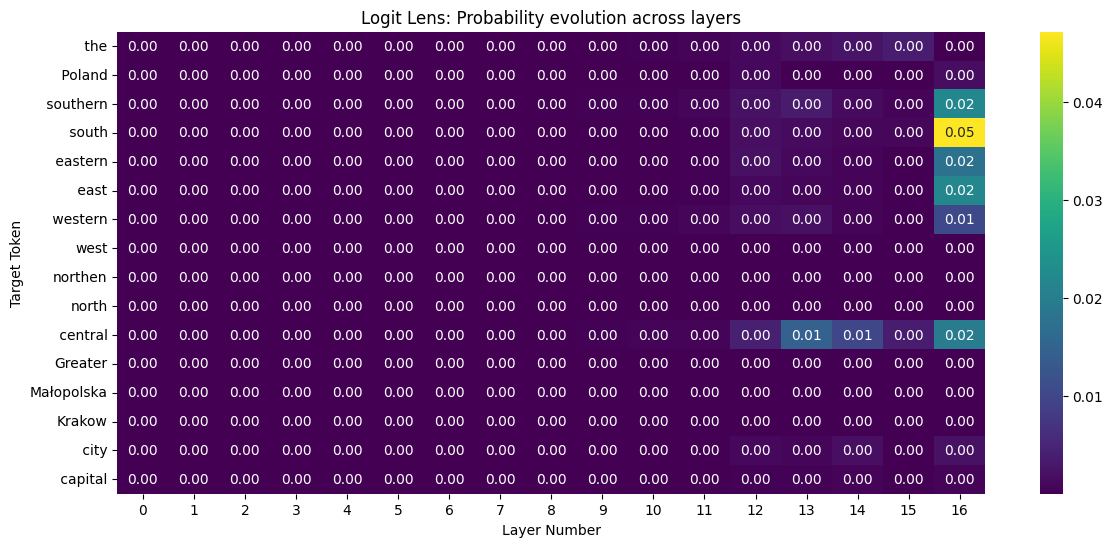

In [12]:
target_words = [' the', ' Poland', ' southern', ' south', ' eastern', ' east', ' western', 'west', 'northen', 'north',' central', 'Greater', 'Małopolska', 'Krakow', ' city', ' capital']

target_ids = []
found_labels = []

print("Token IDs:")
for word in target_words:
    # encode może zwracać listę, bierzemy ID. 
    # add_special_tokens=False żeby nie dodawać BOS/EOS jeśli nie trzeba
    ids = tokenizer.encode(word, add_special_tokens=False)
    
    # Zabezpieczenie: bierzemy ostatni ID (jeśli słowo rozbiło się na pod-tokeny)
    if len(ids) > 0:
        tid = ids[-1] 
        target_ids.append(tid)
        found_labels.append(word)
        print(f"'{word}' -> ID: {tid}")
    else:
        print(f"Warning: '{word}' nie znaleziono w słowniku.")

# --- 2. ZBIERANIE DANYCH ---
# Macierz: wiersze = warstwy, kolumny = nasze target tokeny
probs_history = []

for i, stream in enumerate(residual_streams):
    v = stream.squeeze()
    
    # Upewnij się, że v to tensor float32
    if not isinstance(v, torch.Tensor):
        v = torch.tensor(v, dtype=torch.float32)
    
    # Pobierz wektor tylko dla OSTATNIEJ pozycji w sekwencji (tam gdzie model zgaduje 'next token')
    # Jeśli v ma kształt [seq_len, hidden_dim], bierzemy ostatni wiersz
    if v.ndim > 1:
        final_vector = v[-1, :]
    else:
        final_vector = v

    # Projekcja na słownik (Logity)
    # UWAGA: Dla pełnej poprawności naukowej, przed embed_out powinieneś 
    # zaaplikować LayerNorm (model.ln_final), jeśli embed_out tego nie robi.
    vocab_logits = model.embed_out(final_vector)
    
    # Zmieniamy logity na prawdopodobieństwa (0.0 - 1.0) używając Softmax
    # To sprawia, że warstwy są porównywalne
    vocab_probs = torch.softmax(vocab_logits, dim=-1)
    
    # Wyciągamy prawdopodobieństwa tylko dla naszych targetów
    current_layer_probs = [vocab_probs[tid].item() for tid in target_ids]
    probs_history.append(current_layer_probs)

# --- 3. WIZUALIZACJA ---
# Konwersja do numpy i transpozycja (żeby Warstwy były na osi X, a Tokeny na Y)
data = np.array(probs_history).T 

plt.figure(figsize=(14, 6))
sns.heatmap(
    data, 
    annot=True,            # Pokaż liczby w kratkach
    fmt=".2f",             # Formatowanie liczb (2 miejsca po przecinku)
    cmap="viridis",        # Kolorystyka (ciemny = 0, jasny = 1)
    xticklabels=range(len(residual_streams)), # Oś X: Warstwy
    yticklabels=found_labels                  # Oś Y: Tokeny
)

plt.xlabel("Layer Number")
plt.ylabel("Target Token")
plt.title("Logit Lens: Probability evolution across layers")
plt.show()

## Activation Patching experiment

In [ ]:
from transformer_lens import HookedTransformer
from transformer_lens import utils
import plotly.express as px

model_hooked = HookedTransformer.from_pretrained("EleutherAI/pythia-1b")

# 1. Definicja promptów
clean_prompt = "The Eiffel Tower is located in"
corrupt_prompt = "The Roman Colosseum is located in"
target_token = " Paris" # To chcemy "odzyskać" w przeszczepie

# Tokenizacja
clean_tokens = model_hooked.to_tokens(clean_prompt)
corrupt_tokens = model_hooked.to_tokens(corrupt_prompt)
target_token_id = model_hooked.to_single_token(target_token)

# Sprawdźmy czy prompty mają tę samą długość (kluczowe dla patchingu!)
assert clean_tokens.shape == corrupt_tokens.shape, "Prompty muszą mieć tę samą długość tokenów"

# 2. Clean Run - Zbieramy Cache (oryginalne aktywacje Eiffla)
# return_type="logits" nie jest tu kluczowe, ale cache jest
clean_logits, clean_cache = model_hooked.run_with_cache(clean_tokens)

# 3. Funkcja metryki (Logit Difference)
# Mierzymy różnicę: Logit("Paris") - Logit("Rome"). 
# Im wyższa, tym bardziej model myśli o Paryżu.
def get_logit_diff(logits, target_id):
    # Bierzemy logit dla targetu (Paris) w ostatniej pozycji
    # logits shape: [batch, seq_len, vocab]
    return logits[0, -1, target_id]

# Obliczamy baseline (bez patchingu)
corrupt_logits, _ = model_hooked.run_with_cache(corrupt_tokens)
baseline_logit = get_logit_diff(corrupt_logits, target_token_id)
print(f"Baseline (Colosseum prompt) logit for 'Paris': {baseline_logit.item():.4f}")

# 4. Pętla Patchingu (Eksperyment)
patching_results = []

# Iterujemy przez każdą warstwę
for layer in range(model_hooked.cfg.n_layers):
    
    # Nazwa hooka dla residual stream w danej warstwie
    hook_name = f"blocks.{layer}.hook_resid_pre" 
    
    # Definiujemy funkcję hooka ("chirurga")
    def patch_resid_stream(activations, hook):
        # activations: [batch, seq_len, d_model] to aktywacje "Colosseum"
        # clean_cache[hook.name]: to zapisane aktywacje "Eiffel"
        
        # Wykonujemy przeszczep. 
        # Możemy podmienić wszystko, albo tylko ostatni token. 
        # Tutaj podmieniamy CAŁY residual stream w tej warstwie.
        activations[:, :, :] = clean_cache[hook.name][:, :, :]
        return activations

    # Uruchamiamy model z hookiem
    patched_logits = model_hooked.run_with_hooks(
        corrupt_tokens,
        fwd_hooks=[(hook_name, patch_resid_stream)]
    )

    # Decode the top-k tokens for the last position in patched_logits
    if layer == model_hooked.cfg.n_layers - 1:
        print(f"\nTop tokens after patching at layer {layer}:")
        topk = 10
        top_probs, top_indices = patched_logits[:, -1, :].softmax(dim=-1).topk(topk)
        for i in range(topk):
            tid = top_indices[0, i].item()
            token_str = model_hooked.tokenizer.decode([tid])
            prob = top_probs[0, i].item()
            print(f"Token: {token_str} (id: {tid}) - Probability: {prob:.6f}")
    
    # Mierzymy efekt
    score = get_logit_diff(patched_logits, target_token_id)
    patching_results.append(score.item())

# 5. Wizualizacja
import pandas as pd
df = pd.DataFrame({
    "Layer": range(len(patching_results)),
    "Logit for 'Paris'": patching_results
})

fig = px.line(
    df, 
    x="Layer", 
    y="Logit for 'Paris'", 
    title="Activation Patching: Przywracanie 'Paris' w prompcie o Koloseum",
    labels={"Logit for 'Paris'": "Siła aktywacji 'Paris' (Logit)"},
    markers=True
)

# Dodajemy linię baseline
fig.add_hline(y=baseline_logit.item(), line_dash="dash", annotation_text="Baseline (Rome context)")

fig.show()

Loaded pretrained model EleutherAI/pythia-1b into HookedTransformer
Baseline (Colosseum prompt) logit for 'Paris': 10.9243
Token:  Paris (id: 7785) - Probability: 0.795823
Token:  the (id: 253) - Probability: 0.132229
Token:  France (id: 6181) - Probability: 0.014334
Token:  Paris (id: 7785) - Probability: 0.795823
Token:  the (id: 253) - Probability: 0.132229
Token:  France (id: 6181) - Probability: 0.014334
Token:  Paris (id: 7785) - Probability: 0.795823
Token:  the (id: 253) - Probability: 0.132229
Token:  France (id: 6181) - Probability: 0.014334
Token:  Paris (id: 7785) - Probability: 0.795823
Token:  the (id: 253) - Probability: 0.132229
Token:  France (id: 6181) - Probability: 0.014334
Token:  Paris (id: 7785) - Probability: 0.795823
Token:  the (id: 253) - Probability: 0.132229
Token:  France (id: 6181) - Probability: 0.014334
Token:  Paris (id: 7785) - Probability: 0.795823
Token:  the (id: 253) - Probability: 0.132229
Token:  France (id: 6181) - Probability: 0.014334
Token: 

In [19]:
from transformer_lens import HookedTransformer
import torch

# Ustawienia (upewnij się, że model jest załadowany)
clean_prompt = "The Eiffel Tower is located in"
corrupt_prompt = "The Roman Colosseum is located in" # Dodałem "Roman" żeby wyrównać długość (częsty problem!)

# 1. Weryfikacja długości tokenów (Kluczowe!)
clean_tokens = model_hooked.to_tokens(clean_prompt)
corrupt_tokens = model_hooked.to_tokens(corrupt_prompt)

if clean_tokens.shape[1] != corrupt_tokens.shape[1]:
    print(f"UWAGA: Różne długości! Eiffel: {clean_tokens.shape[1]}, Colosseum: {corrupt_tokens.shape[1]}")
    # Tutaj musisz ręcznie dopasować prompty, żeby miały tyle samo tokenów
else:
    print(f"Długość tokenów zgodna: {clean_tokens.shape[1]}")

# 2. Clean Run (Cache Eiffla)
_, clean_cache = model_hooked.run_with_cache(clean_tokens)

# 3. Funkcja do generowania z hookiem
def generate_with_patch(layer_to_patch):
    hook_name = f"blocks.{layer_to_patch}.hook_resid_pre"
    
    # Definicja hooka
    def patch_hook(activations, hook):
        # activations shape: [batch, seq_len, d_model]
        # clean_cache shape: [batch, seq_len, d_model]
        
        # POPRAWKA: Bierzemy [-1] również z clean_cache!
        activations[:, -1, :] = clean_cache[hook.name][:, -1, :] 
        
        return activations
    
    # Używamy context managera 'hooks' - to pozwala na generate()
    with model_hooked.hooks(fwd_hooks=[(hook_name, patch_hook)]):
        # Generujemy 5 nowych tokenów
        output = model_hooked.generate(corrupt_tokens, max_new_tokens=5, verbose=False)
    
    return model_hooked.to_string(output)[0]

# --- EKSPERYMENT ---

# Sprawdźmy co się dzieje w kilku kluczowych punktach
print(f"\nOryginalny prompt (bez patchingu):")
print(model_hooked.generate(corrupt_tokens, max_new_tokens=5, verbose=False))

print("\n--- Rozpoczynamy Patching ---")
layers_to_check = [0, 5, 10, 12, 15] # Sprawdźmy wybrane warstwy

for layer in layers_to_check:
    generated_text = generate_with_patch(layer, )
    print(f"Patching Layer {layer}:")
    print(f"   Output: '{generated_text}'")

Długość tokenów zgodna: 9

Oryginalny prompt (bez patchingu):
tensor([[    0,   510,  8370,  2065, 37554,   360,   310,  4441,   275,   253,
          9129, 24703,   275,   752]], device='mps:0')

--- Rozpoczynamy Patching ---
Patching Layer 0:
   Output: '<|endoftext|>The Roman Colosseum is located in Rome the the's Italy'
Patching Layer 5:
   Output: '<|endoftext|>The Roman Colosseum is located in Rome one Min the the'
Patching Layer 10:
   Output: '<|endoftext|>The Roman Colosseum is located in Rome Los Rome Rome Rome'
Patching Layer 12:
   Output: '<|endoftext|>The Roman Colosseum is located in Paris Paris Paris the Paris'
Patching Layer 15:
   Output: '<|endoftext|>The Roman Colosseum is located in Paris Paris Paris Paris Paris'


Szukamy momentu aktywacji dla tokenu: ' Paris' (ID: 7785)
Rozpoczynam skanowanie warstw...


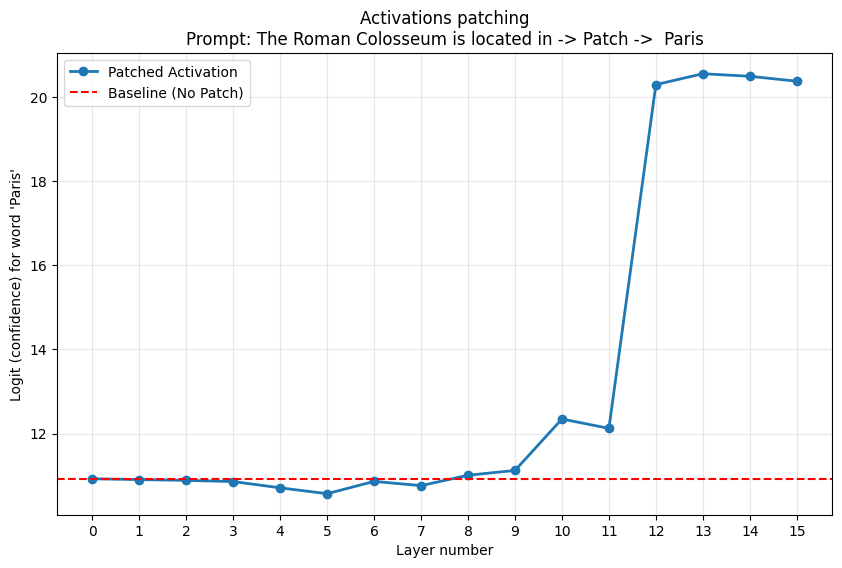

In [23]:
# --- 1. KONFIGURACJA DANYCH ---
clean_prompt = "The Eiffel Tower is located in"
corrupt_prompt = "The Roman Colosseum is located in"
target_word = " Paris"

# Tokenizacja
clean_tokens = model_hooked.to_tokens(clean_prompt)
corrupt_tokens = model_hooked.to_tokens(corrupt_prompt)
target_id = model_hooked.to_single_token(target_word)

# Wyrównanie długości (prosty hack, w razie gdyby prompty były różne)
min_len = min(clean_tokens.shape[1], corrupt_tokens.shape[1])
clean_tokens = clean_tokens[:, :min_len]
corrupt_tokens = corrupt_tokens[:, :min_len]

print(f"Szukamy momentu aktywacji dla tokenu: '{target_word}' (ID: {target_id})")

# --- 2. CLEAN RUN (Zbieramy 'prawdę' o Eifflu) ---
# Musimy mieć zapisane aktywacje, żeby mieć co wstrzykiwać
_, clean_cache = model_hooked.run_with_cache(clean_tokens)

# --- 3. PĘTLA PATCHINGU (Skanowanie warstw) ---
patching_scores = []

print("Rozpoczynam skanowanie warstw...")

for layer in range(model_hooked.cfg.n_layers):
    # Nazwa miejsca, w które celujemy (Residual Stream przed warstwą)
    hook_name = f"blocks.{layer}.hook_resid_pre"
    
    # Definicja 'chirurga' - podmienia tylko ostatni token w tej konkretnej warstwie
    def patch_last_token(activations, hook):
        # activations: to co widzi model (Colosseum)
        # clean_cache: to co chcemy wstrzyknąć (Eiffel)
        # [:, -1, :] oznacza: wszystkie batche, OSTATNI token, wszystkie neurony
        activations[:, -1, :] = clean_cache[hook.name][:, -1, :]
        return activations

    # Uruchomienie modelu z "wirusem" (hookiem)
    patched_logits = model_hooked.run_with_hooks(
        corrupt_tokens,
        fwd_hooks=[(hook_name, patch_last_token)]
    )
    
    # Wyciągamy logit (siłę sygnału) dla słowa "Paris"
    # Logit jest lepszy niż prawdopodobieństwo do wykresów (bardziej liniowy)
    final_logit = patched_logits[0, -1, target_id].item()
    patching_scores.append(final_logit)

# --- 4. RYSOWANIE WYKRESU ---
# Obliczamy baseline (ile "Paris" ma punktów w zdaniu o Koloseum bez zmian)
logits_baseline, _ = model_hooked.run_with_cache(corrupt_tokens)
baseline_score = logits_baseline[0, -1, target_id].item()

plt.figure(figsize=(10, 6))
plt.plot(range(model_hooked.cfg.n_layers), patching_scores, marker='o', linewidth=2, label="Patched Activation")
plt.axhline(y=baseline_score, color='r', linestyle='--', label="Baseline (No Patch)")

plt.title(f"Activations patching\nPrompt: {corrupt_prompt} -> Patch -> {target_word}")
plt.xlabel("Layer number")
plt.ylabel("Logit (confidence) for word 'Paris'")
plt.xticks(range(model_hooked.cfg.n_layers)) # Pokaż wszystkie numery warstw
plt.grid(True, alpha=0.3)
plt.legend()

plt.show()